# DustSCAN Model Performance Visualization

**Overview**  
This notebook is dedicated to analyzing the training and validation metrics of the DustSCAN semantic segmentation model. It parses the generated TensorBoard event files and provides comprehensive visualizations of model performance over the training lifecycle.

**Structure:**
1. Environment Setup & Imports
2. TensorBoard Log Parsing
3. Loss Trajectory Analysis
4. Evaluation Metrics (IoU & F1 Score)

## 1. Environment Setup & Imports

In [10]:
import os
import sys
import glob
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')


## 2. TensorBoard Log Parsing

We extract scalar values (losses and metrics) from the latest training run's TensorBoard logs.

In [ ]:
# Locate the latest TensorBoard log
log_dir = '../outputs/runs/dustscan_experiment'
event_files = sorted(glob.glob(os.path.join(log_dir, 'events.out.tfevents.*')), key=os.path.getmtime)

def extract_scalars(event_file):
    ea = EventAccumulator(event_file, size_guidance={'scalars': 0})
    ea.Reload()
    
    data = {}
    for tag in ea.Tags()['scalars']:
        events = ea.Scalars(tag)
        data[tag] = pd.DataFrame([(e.step, e.value) for e in events], columns=['step', tag])
        
    if not data:
        return pd.DataFrame()
        
    # Merge all DataFrames on step
    df = list(data.values())[0]
    for v in list(data.values())[1:]:
        df = pd.merge(df, v, on='step', how='outer')
    return df

dfs = []
cumulative_steps = 0
for f in event_files:
    df = extract_scalars(f)
    if not df.empty:
        df['step'] = df['step'] + cumulative_steps
        cumulative_steps = df['step'].max() + 1
        dfs.append(df)

if dfs:
    metrics_df = pd.concat(dfs).sort_values('step').reset_index(drop=True)
    metrics_df = metrics_df.ffill()
    
    metrics_df = metrics_df[metrics_df['step'] <= 55]
    display(metrics_df.tail())
else:
    print("No scalar events found.")
    metrics_df = pd.DataFrame()


,step,Loss/Train,Loss/Validation,Metrics/IoU,Metrics/F1_Score
51,51,0.251451,0.300589,0.710285,0.830604
52,52,0.247848,0.300795,0.713577,0.832851
53,53,0.245147,0.300520,0.715901,0.834432
54,54,0.252871,0.305494,0.715080,0.833874
55,55,0.251087,0.299054,0.702315,0.825129


## 3. Loss Trajectory Analysis

Comparing Training Loss and Validation Loss to monitor convergence and detect potential overfitting.

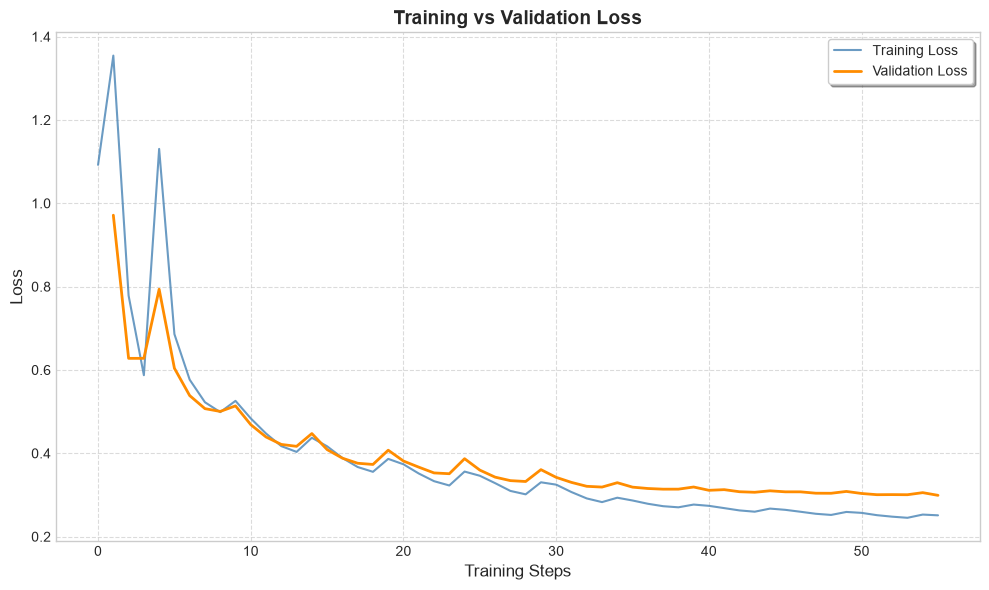

In [12]:
if not metrics_df.empty and 'Loss/Train' in metrics_df.columns and 'Loss/Validation' in metrics_df.columns:
    plt.figure(figsize=(10, 6))
    plt.plot(metrics_df['step'], metrics_df['Loss/Train'], label='Training Loss', alpha=0.8, color='steelblue', linewidth=1.5)
    
    val_df = metrics_df.dropna(subset=['Loss/Validation'])
    plt.plot(val_df['step'], val_df['Loss/Validation'], label='Validation Loss', color='darkorange', linewidth=2)
    
    plt.title('Training vs Validation Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Training Steps', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Loss data not found in logs.")


## 4. Evaluation Metrics (IoU & F1 Score)

Visualizing the key segmentation metrics over validation steps to evaluate the model's predictive quality.

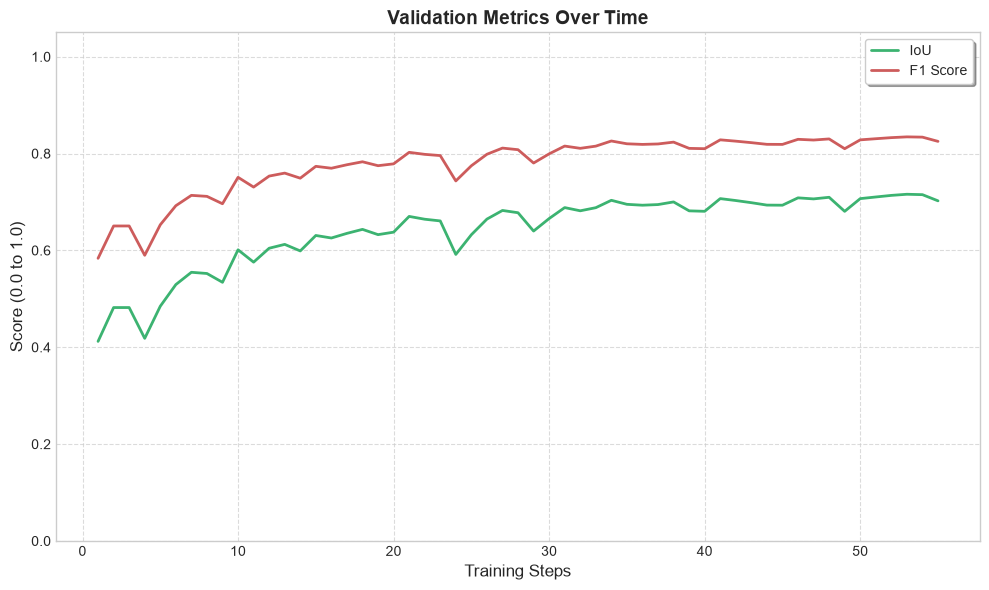

In [13]:
metrics_to_plot = ['Metrics/IoU', 'Metrics/F1_Score']
available_metrics = [m for m in metrics_to_plot if m in metrics_df.columns]

if available_metrics:
    plt.figure(figsize=(10, 6))
    colors = ['mediumseagreen', 'indianred']
    
    for idx, metric in enumerate(available_metrics):
        m_df = metrics_df.dropna(subset=[metric])
        label_name = metric.split('/')[-1].replace('_', ' ')
        plt.plot(m_df['step'], m_df[metric], label=label_name, linewidth=2, color=colors[idx % len(colors)])
        
    plt.title('Validation Metrics Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Training Steps', fontsize=12)
    plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
    plt.ylim(0, 1.05)
    plt.legend(frameon=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Validation metrics not found in logs.")
